In [22]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            print(file.keys())
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_3d_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        Input: (Time, Z, Y) -> Output: (Days, Z, Y)
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        
        # We reshape to (Days, 4_steps, Z, Y)
        # data.shape[1] is Z, data.shape[2] is Y
        reshaped_data = data[:num_days * 4].reshape(num_days, 4, data.shape[1], data.shape[2])
        
        # Calculate mean across the 4-step axis (axis 1)
        daily_mean = reshaped_data.mean(axis=1)
        
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        PC2 = eof_instance.PC[1]
        
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)
        PC2_normalized = PC2 / PC2.std(axis=0)
        

        return EOF_modes, PCs_normalized, PC2_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)



In [23]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

# --- Main Script ---

# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
auto_length = 100
window_length = 2048
split_to_chunk = True
latitudes = np.linspace(0, 90, 32)
variable_name = "u"

# 1. Configuration: Define all experiments
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01}",
        "color": col,
        "linestyle": "-", 
        "path": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "path": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--", 
    "path": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# 2. Data Processing Loop
PC1_results = []


valid_experiments_indices = []

for i, exp in enumerate(experiments):
    print(f"Processing: {exp['label']}")
    
    # Load Data
    u_data = moist_dycore.load_data(exp["path"], variable_name)
    
    if u_data is None:
        continue

    print(f"  Data shape: {u_data.shape}")

    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    print(f"  Daily mean shape: {u_daily.shape}")
    
    # Calculate EOF
    # Slicing assumes [Time, Lat] or [Time, ... Lat ...] where 32: selects the desired hemisphere
    try:
        data_for_eof = u_daily[5000:, 32:]
        
        # Check if dimensions match latitudes array
        if data_for_eof.shape[1] != len(latitudes):
            print(f"  Warning: Data latitude dim ({data_for_eof.shape[1]}) does not match latitudes array ({len(latitudes)})")

        EOFs, PC_normalized, PC2_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(
            data_for_eof, 
            latitudes, 
            n_components=32, 
            field="1D"
        )
        
        # Assuming PC_normalized is shape (Time, Modes), select PC1 (index 0)
        # If your EOF package returns (Time, Modes), we take all times for mode 0
        if PC_normalized.ndim > 1:
             pc1_series = PC_normalized[:, 0]            
        else:
             pc1_series = PC_normalized # Fallback if it returns 1D
            
        
        PC1_results.append(pc1_series)
        
        valid_experiments_indices.append(i)
        print(f"  PC1 extracted, length: {pc1_series.shape[0]}\n")
        
    except Exception as e:
        print(f"  Error in EOF calculation for {exp['label']}: {e}\n")

# 3. Calculate Autocorrelation & Plot
autocorr_results = []

print("Calculating Autocorrelation...")
for pc_data in PC1_results:
    autocorr = moist_dycore.symmetric_autocorr(
        pc_data, 
        max_lag=auto_length, 
        split_to_chunk=split_to_chunk, 
        window_length=window_length,
        overlap=int(window_length/2) # Ensure this matches your desired overlap
    )
    autocorr_results.append(autocorr)


# lag_day for plotting
lag_day = np.arange(-auto_length, auto_length + 1)


Processing: L = 0.0
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.1
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.2
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.3
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.4
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: L = 0.5
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: Midlat
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: (19500, 64)
  PC1 extracted, length: 14500

Processing: Trop
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  Daily mean shape: 

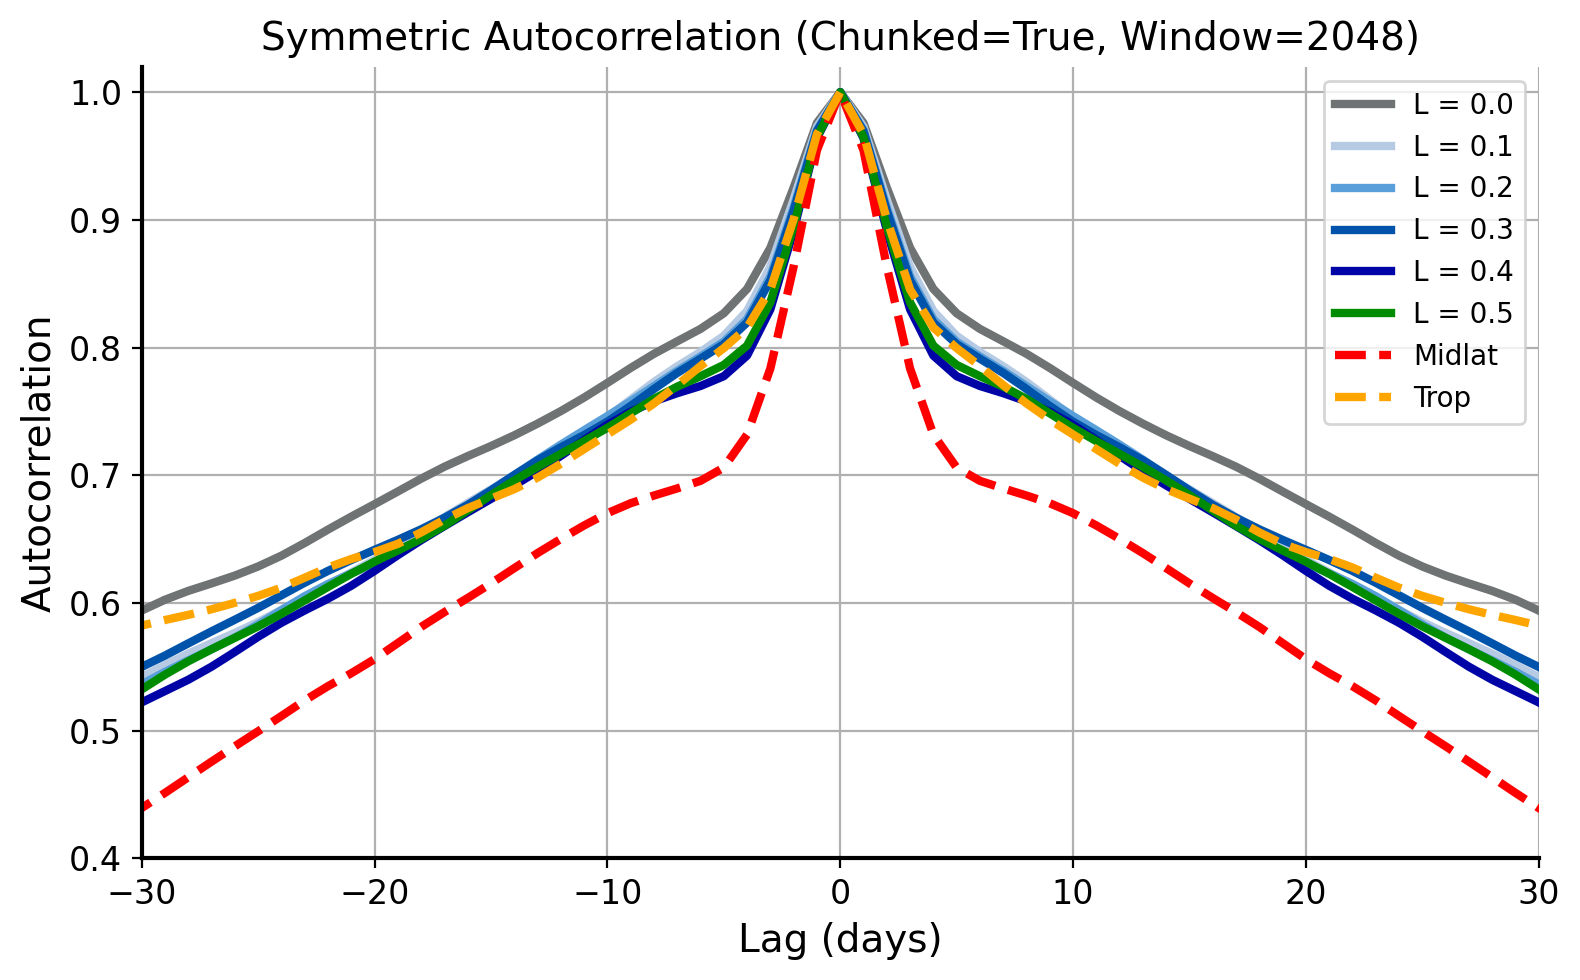

In [24]:
# Lag_day for plotting
lag_day_full = np.arange(-auto_length, auto_length + 1)

# Plotting
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for idx, exp_idx in enumerate(valid_experiments_indices):
    exp_config = experiments[exp_idx]
    ax.plot(lag_day_full, autocorr_results[idx], 
            label=exp_config["label"], 
            color=exp_config["color"], 
            linestyle=exp_config["linestyle"],
            lw=3)

# Customize plot
ax.set_title(f"Symmetric Autocorrelation (Chunked={split_to_chunk}, Window={window_length})", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.4, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import h5py

# --- 1. Configuration: Define all experiments (PR + Midlat + Trop) ---
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o",
        "L_val": val * 0.01,
        # Path for U variable
        "path_u": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment (Red, Dotted)
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment (Orange, Dotted)
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

num_exp = len(experiments)

# --- 2. Data Calculation Loop ---

start_day = 500 + 5000
end_day   = 20000
day_length = len(np.arange(start_day, end_day))

print(f"start_day = {start_day}, end_day = {end_day}, total day = {day_length}")
print(f"Total Experiments: {num_exp}")

# Initialize arrays
Uzm_all = np.zeros((num_exp, day_length, 64))
EMF = np.zeros((num_exp, day_length, 64))

# Loop through all experiments
for i, exp in enumerate(experiments):
    path_u = exp["path_u"]
    # Derive EMF path from U path by replacing folder/filenames
    path_emf = path_u.replace("u_add_time_dim", "EMF_add_time_dim")\
                     .replace("u_climatology", "EMF_climatology")\
                     .replace("/u/", "/EMF/") # Just in case directory structure varies slightly
    
    print(f"Processing {exp['label']}...")
    
    # 1. Load U
    try:
        with h5py.File(path_u, 'r') as f:
            # Slicing logic from your code
            # data shape expected: (Time, Y) or (Time, Z, Y)? 
            # Your snippet used: f["u"][...].reshape(...,4,64).mean(axis=1)
            # This implies raw data is 4x daily resolution.
            
            raw_u = f["u"][int(start_day-500)*4:, :]
            # Reshape to (Days, 4, Lat) and mean over daily cycle
            limit = min(day_length * 4, raw_u.shape[0])
            # Ensure we don't go out of bounds if file is shorter
            valid_days = limit // 4
            
            Uzm_all[i, :valid_days, :] = raw_u[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading U for {exp['label']}: {e}")

    # 2. Load EMF
    try:
        with h5py.File(path_emf, 'r') as f:
            raw_emf = f["EMF"][int(start_day-500)*4:, :]
            limit = min(day_length * 4, raw_emf.shape[0])
            valid_days = limit // 4
            EMF[i, :valid_days, :] = raw_emf[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)
    except Exception as e:
        print(f"  Error loading EMF for {exp['label']}: {e}\n  (Path tried: {path_emf})")


# --- 3. Calculate dmdy ---
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy ** 2

dmdy = np.zeros((num_exp, day_length, 64))

for a in range(num_exp):
    Mzm = EMF[a]
    
    # Central difference for interior points
    for k in range(1, 64-1):
        dmdy[a,:,k] = -(Mzm[:,k+1] * (cy[k]**2) - Mzm[:,k-1]* (cy[k]**2)) / \
                       (radius * (cy[k]**2) * (yd[k+1] - yd[k-1]))
    
    # Boundary conditions
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))

print(f"dmdy calculation complete. Shape: {dmdy.shape}")

start_day = 5500, end_day = 20000, total day = 14500
Total Experiments: 8
Processing L = 0.0...
Processing L = 0.1...
Processing L = 0.2...
Processing L = 0.3...
Processing L = 0.4...
Processing L = 0.5...
Processing Midlat...
Processing Trop...
dmdy calculation complete. Shape: (8, 14500, 64)


In [26]:
# --- 4. Renew PP_all_u and m_fig3 for ALL 8 experiments ---
num_lat = 32
m_fig3_results = np.zeros((8,14500))
m2_fig3_results = np.zeros((8,14500))


# Update array dimensions to match the new number of experiments (8)
num_exp_updated = len(experiments)

# Re-initialize arrays with the correct shape
PP_all_u = np.zeros((num_exp_updated, day_length))
PP2_all_u = np.zeros((num_exp_updated, day_length))

m_fig3 = np.zeros((num_exp_updated, day_length))
m2_fig3 = np.zeros((num_exp_updated, day_length))


print(f"Re-calculating EOF and projections for {num_exp_updated} experiments...")

# Re-run the generation of m_fig3 and PP_all_u using the updated data
for exp_idx in range(num_exp_updated):
    # Apply cosine latitude weighting
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    
    # Compute EOF (assuming your custom EOF class/function is already imported/defined)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    # Store Principal Component and EOF pattern
    PP_all_u[exp_idx]  = single_EOF_u.PC[0]
    PP2_all_u[exp_idx] = single_EOF_u.PC[1]
    
    EOF_u_final  = single_EOF_u.EOF[0]
    EOF2_u_final = single_EOF_u.EOF[1]
    
    
    # Project dmdy onto the EOF to get the m(t) forcing time series
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)
    m2_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF2_u_final)

    m_fig3_results[exp_idx]  = m_fig3[exp_idx]  / m_fig3[exp_idx].std()
    m2_fig3_results[exp_idx] = m2_fig3[exp_idx] / m2_fig3[exp_idx].std()
    

print(f"Successfully updated m_fig3! New shape: {m_fig3.shape}")

# Now you can safely proceed to your Welch's method spectral analysis block!

Re-calculating EOF and projections for 8 experiments...
Successfully updated m_fig3! New shape: (8, 14500)


In [27]:
m_fig3.shape

(8, 14500)

In [28]:
PP_all_u.shape

(8, 14500)

# Cal b

In [29]:
# Doing 6 hourly data
# --- Main Script ---

# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
split_to_chunk = True
latitudes = np.linspace(0, 90, 32)
variable_name = "u"

# 1. Configuration: Define all experiments
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o",
        "L_val": val * 0.01,
        # Path for U variable
        "path_u": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment (Red, Dotted)
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment (Orange, Dotted)
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})


# 2. Data Processing Loop
PC1_results_6hourly = []

valid_experiments_indices = []

for i, exp in enumerate(experiments):
    print(f"Processing: {exp['label']}")
    
    # Load Data
    u_data = moist_dycore.load_data(exp["path_u"], variable_name)
    
    if u_data is None:
        continue

    print(f"  Data shape: {u_data.shape}")    
    # Calculate EOF

    data_for_eof = u_data[5000*4:, 32:]
    
    # Check if dimensions match latitudes array
    if data_for_eof.shape[1] != len(latitudes):
        print(f"  Warning: Data latitude dim ({data_for_eof.shape[1]}) does not match latitudes array ({len(latitudes)})")

    EOFs, PC_normalized, PC2_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(
        data_for_eof, 
        latitudes, 
        n_components=32, 
        field="1D"
    )
    
    # Assuming PC_normalized is shape (Time, Modes), select PC1 (index 0)
    # If your EOF package returns (Time, Modes), we take all times for mode 0
    if PC_normalized.ndim > 1:
         pc1_series = PC_normalized[:, 0]            
    else:
         pc1_series = PC_normalized # Fallback if it returns 1D
        
    
    PC1_results_6hourly.append(pc1_series)
    
    valid_experiments_indices.append(i)
    print(f"  PC1 extracted, length: {pc1_series.shape[0]}\n")
        


Processing: L = 0.0
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: L = 0.1
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: L = 0.2
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: L = 0.3
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: L = 0.4
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: L = 0.5
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: Midlat
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000

Processing: Trop
<KeysViewHDF5 ['u']>
  Data shape: (78000, 64)
  PC1 extracted, length: 58000



In [30]:
PC1_results_6hourly[0].shape

(58000,)

In [31]:
# --- 1. Configuration: Define all experiments (PR + Midlat + Trop) ---
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]
pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o",
        "L_val": val * 0.01,
        # Path for U variable
        "path_u": f"/data92/PeterChang/1120_preprocessing/PR{val}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    })

# B. Midlat experiment (Red, Dotted)
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang/Moist_Dycore_only_midlatitude_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

# C. Trop experiment (Orange, Dotted)
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5, # Plotted at L=0.5 for comparison
    "path_u": "/data92/PeterChang2/Moist_Dycore_only_tropical_LH/PR50/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
})

num_exp = len(experiments)

# Initialize arrays
Uzm_all = np.zeros((num_exp, day_length*4, 64))
EMF = np.zeros((num_exp, day_length*4, 64))

# Loop through all experiments
for i, exp in enumerate(experiments):
    path_u = exp["path_u"]
    # Derive EMF path from U path by replacing folder/filenames
    path_emf = path_u.replace("u_add_time_dim", "EMF_add_time_dim")\
                     .replace("u_climatology", "EMF_climatology")\
                     .replace("/u/", "/EMF/") # Just in case directory structure varies slightly    
    print(f"Processing {exp['label']}...")
    
    # 1. Load U
    with h5py.File(path_u, 'r') as f:
        raw_u = f["u"][5000 * 4:, :]
        Uzm_all[i, :, :] = raw_u#[:valid_days*4, :].reshape(valid_days, 4, 64).mean(axis=1)

    # 2. Load EMF
    with h5py.File(path_emf, 'r') as f:
        raw_emf = f["EMF"][5000 * 4:, :]
        EMF[i, :, :] = raw_emf


# --- 3. Calculate dmdy ---
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy ** 2

dmdy = np.zeros((num_exp, day_length*4, 64))

for a in range(num_exp):
    Mzm = EMF[a]
    
    # Central difference for interior points
    for k in range(1, 64-1):
        dmdy[a,:,k] = -(Mzm[:,k+1] * (cy[k]**2) - Mzm[:,k-1]* (cy[k]**2)) / \
                       (radius * (cy[k]**2) * (yd[k+1] - yd[k-1]))
    
    # Boundary conditions
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))

print(f"dmdy calculation complete. Shape: {dmdy.shape}")

Processing L = 0.0...
Processing L = 0.1...
Processing L = 0.2...
Processing L = 0.3...
Processing L = 0.4...
Processing L = 0.5...
Processing Midlat...
Processing Trop...
dmdy calculation complete. Shape: (8, 58000, 64)


In [32]:
# --- 4. Renew PP_all_u and m_fig3 for ALL 8 experiments ---
num_lat = 32
m_fig3_results = np.zeros((8, 14500 * 4))


# Update array dimensions to match the new number of experiments (8)
num_exp_updated = len(experiments)

# Re-initialize arrays with the correct shape
PP_all_u = np.zeros((num_exp_updated, day_length*4))
m_fig3 = np.zeros((num_exp_updated, day_length*4))

print(f"Re-calculating EOF and projections for {num_exp_updated} experiments...")

# Re-run the generation of m_fig3 and PP_all_u using the updated data
for exp_idx in range(num_exp_updated):
    # Apply cosine latitude weighting
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    
    # Compute EOF (assuming your custom EOF class/function is already imported/defined)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    # Store Principal Component and EOF pattern
    PP_all_u[exp_idx]  = single_EOF_u.PC[0]
    EOF_u_final  = single_EOF_u.EOF[0]
    
    # Project dmdy onto the EOF to get the m(t) forcing time series
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)

    m_fig3_results[exp_idx]  = m_fig3[exp_idx]  / m_fig3[exp_idx].std()
    

print(f"Successfully updated m_fig3! New shape: {m_fig3.shape}")



Re-calculating EOF and projections for 8 experiments...
Successfully updated m_fig3! New shape: (8, 58000)


In [33]:
print(m_fig3_results[0].shape)
print(PC1_results_6hourly[0].shape)

(58000,)
(58000,)


In [34]:
z = np.array(PC1_results_6hourly)
m = np.array(m_fig3_results)

In [35]:
z[0].shape

(58000,)

In [36]:
m[0].shape

(58000,)

<>:107: SyntaxWarning: invalid escape sequence '\o'
<>:121: SyntaxWarning: invalid escape sequence '\o'
<>:107: SyntaxWarning: invalid escape sequence '\o'
<>:121: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_347265/1127366694.py:107: SyntaxWarning: invalid escape sequence '\o'
  ax2.plot(freqs_shift, freqs_shift * 2 * np.pi, label="Theoretical $\omega$ ($2\pi f$)", color='black', linestyle=':', linewidth=2)
/tmp/ipykernel_347265/1127366694.py:121: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_title("Imaginary Part of Transfer Function ($\omega$)")


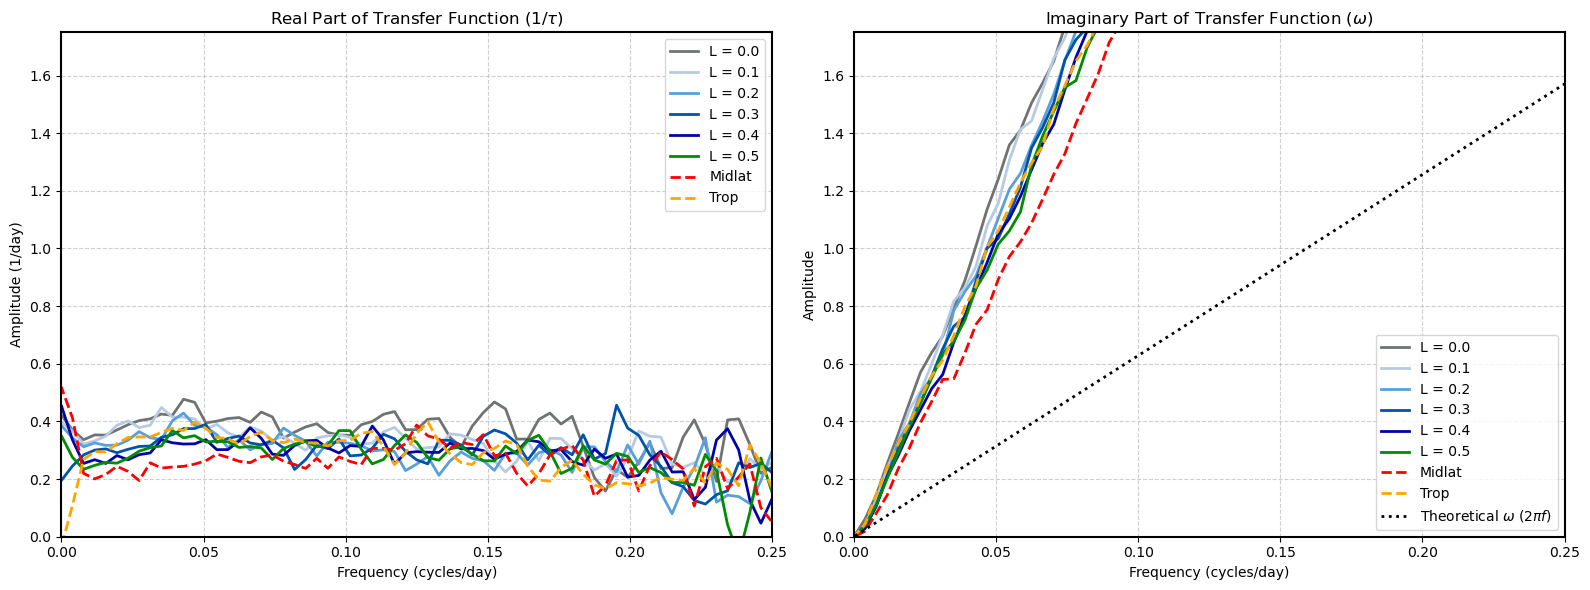

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Configuration (Your exact setup) ---
experiments = []

# A. Standard PR experiments
PR_values = [0, 10, 20, 30, 40, 50]

pr_colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                      [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

for val, col in zip(PR_values, pr_colors):
    experiments.append({
        "label": f"L = {val * 0.01:.1f}",
        "color": col,
        "linestyle": "-",  
        "marker": "o", 
        "L_val": val * 0.01
    })

# B. Midlat experiment
experiments.append({
    "label": "Midlat",
    "color": "red",
    "linestyle": "--", 
    "marker": "*",
    "L_val": 0.5
})

# C. Trop experiment
experiments.append({
    "label": "Trop",
    "color": "orange",
    "linestyle": "--",
    "marker": "*",
    "L_val": 0.5
})

# --- 2. Time & Spectral Parameters for DAILY data ---
# z and m are assumed to be predefined arrays of shape (8, 14500)
# e.g., z.shape == (8, 14500)

dt = 1.0 / 4   # Daily data
segment_length = 256 * 4
overlap = 128 * 4

step_size = segment_length - overlap 

hanning_window = np.hanning(segment_length)
freqs = np.fft.fftfreq(segment_length, d=1/4)
freqs_shift = np.fft.fftshift(freqs)

# --- 3. Figure Setup ---
# Creating two subplots so the 8 lines don't visually overlap too much
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- 4. Data Calculation & Plotting Loop ---
# We use enumerate to get the index 'i' to slice the corresponding row from z and m
for i, exp in enumerate(experiments):
    
    # Extract the 1D time series for the current experiment (length 14500)
    z_exp = z[i, :]
    m_exp = m[i, :]

    # Slice into overlapping segments
    segments_z = np.array([z_exp[j : j + segment_length] for j in range(0, len(z_exp) - segment_length + 1, step_size)])
    segments_m = np.array([m_exp[j : j + segment_length] for j in range(0, len(m_exp) - segment_length + 1, step_size)])
    
    # Apply Hanning window
    windowed_z = segments_z * hanning_window
    windowed_m = segments_m * hanning_window
    
    # Perform FFT along the time axis (axis=1)
    num_segments = len(windowed_z) # 130
    Z = np.zeros((num_segments, segment_length), dtype=complex)
    M = np.zeros((num_segments, segment_length), dtype=complex)
    for i in range(num_segments):
        Z[i, :] = np.fft.fft(windowed_z[i, :])
        M[i, :] = np.fft.fft(windowed_m[i, :])
    
    Z = np.fft.fft(windowed_z, axis=1)
    M = np.fft.fft(windowed_m, axis=1)
    
    # Calculate cross-spectrum and power spectrum
    cross_spec = np.conj(Z) * M
    z_power = Z * np.conj(Z) # np.real(Z * np.conj(Z))
    
    # Average across all 256-day segments to get H for this specific experiment
    H = cross_spec.mean(axis=0) / z_power.mean(axis=0)
    
    # Shift for plotting
    H_real_shift = np.fft.fftshift(H.real)
    H_imag_shift = np.fft.fftshift(H.imag)
    
    # Plot Real part (1 / tau) on ax1
    ax1.plot(freqs_shift, H_real_shift, 
             color=exp["color"], linestyle=exp["linestyle"], label=exp["label"], linewidth=2)
    
    # Plot Imaginary part (omega) on ax2
    ax2.plot(freqs_shift, H_imag_shift, 
             color=exp["color"], linestyle=exp["linestyle"], label=exp["label"], linewidth=2)

# --- 5. Formatting the Plots ---

# Theoretical omega line for the imaginary subplot
ax2.plot(freqs_shift, freqs_shift * 2 * np.pi, label="Theoretical $\omega$ ($2\pi f$)", color='black', linestyle=':', linewidth=2)

# Subplot 1: Real Part (1/tau)
ax1.set_xlim([0, 0.25]) # Zooming in on low frequencies (periods > 4 days)
ax1.set_ylim([0, 1.75]) 
ax1.set_title("Real Part of Transfer Function ($1/\\tau$)")
ax1.set_xlabel("Frequency (cycles/day)")
ax1.set_ylabel("Amplitude (1/day)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Subplot 2: Imaginary Part (omega)
ax2.set_xlim([0, 0.25])
ax2.set_ylim([0, 1.75]) 
ax2.set_title("Imaginary Part of Transfer Function ($\omega$)")
ax2.set_xlabel("Frequency (cycles/day)")
ax2.set_ylabel("Amplitude")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [38]:
segments_z.shape

(112, 1024)

# Cal tau

In [39]:
z.shape

(8, 58000)

In [81]:
"""
L = 0.0 tau_z^2: 113.57256
L = 0.1 tau_z^2: 110.32723
L = 0.2 tau_z^2: 114.25765
L = 0.3 tau_z^2: 119.35275
L = 0.4 tau_z^2: 126.30751
L = 0.5 tau_z^2: 130.80621
Midlat tau_z^2: 107.70893
Trop tau_z^2: 130.27789
"""

tau_all.shape

(8,)

In [86]:
tau_all[0] = np.sqrt(113.57256)
tau_all[1] = np.sqrt(110.32723)
tau_all[2] = np.sqrt(114.25765)
tau_all[3] = np.sqrt(119.35275)
tau_all[4] = np.sqrt(126.30751)
tau_all[5] = np.sqrt(130.80621)
tau_all[6] = np.sqrt(107.70893)
tau_all[7] = np.sqrt(130.27789)



Calculated tau: 10.02 days
Calculated tau: 9.26 days
Calculated tau: 9.63 days
Calculated tau: 11.13 days
Calculated tau: 9.59 days
Calculated tau: 11.13 days
Calculated tau: 8.42 days
Calculated tau: 14.11 days


Text(0.5, 1.0, '$\\tau$')

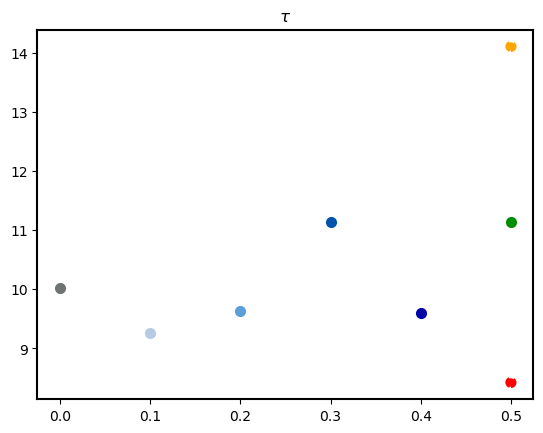

In [85]:
from scipy.optimize import curve_fit

def func(f, alpha, beta):
    z = alpha + 1j *2 * np.pi * f * beta
    return np.concatenate([z.real, z.imag])

tau_all = np.zeros(8)
for j, exp in enumerate(experiments):
    
    # Extract the 1D time series for the current experiment (length 14500)
    z_exp = z[j, :]
    m_exp = m[j, :]
    
    # Slice into overlapping segments
    segments_z = np.array([z_exp[j : j + segment_length] for j in range(0, len(z_exp) - segment_length + 1, step_size)])
    segments_m = np.array([m_exp[j : j + segment_length] for j in range(0, len(m_exp) - segment_length + 1, step_size)])
    
    # Apply Hanning window
    windowed_z = segments_z * hanning_window
    windowed_m = segments_m * hanning_window
    
    # Perform FFT along the time axis (axis=1)
    num_segments = len(windowed_z) # 130
    Z = np.zeros((num_segments, segment_length), dtype=complex)
    M = np.zeros((num_segments, segment_length), dtype=complex)
    for i in range(num_segments):
        Z[i, :] = np.fft.fft(windowed_z[i, :])
        M[i, :] = np.fft.fft(windowed_m[i, :])
    
    Z = np.fft.fft(windowed_z, axis=1)
    M = np.fft.fft(windowed_m, axis=1)
    # Appendix A
    # 1. Calculate the transfer function H = (Z * M*) / (Z * Z*)
    cross_spec = np.conj(Z) * (M)
    z_power = Z * np.conj(Z) 
    
    H_appendix_A = cross_spec[:].mean(axis=0) / z_power[:].mean(axis=0)
    H_appendix_A_shift = np.fft.fftshift(H_appendix_A)
    
    f_fit_indice = np.where((freqs_shift >= 0) & (freqs_shift <= 0.025))
    f_fit = freqs_shift[f_fit_indice]
    
    trans_fit = np.concatenate([H_appendix_A_shift[f_fit_indice].real, H_appendix_A_shift[f_fit_indice].imag])

    # fit tau 
    result, _ = curve_fit(func, f_fit , trans_fit)

    # Extract the optimized parameters
    alpha_fit = result[0]
    beta_fit = result[1]
    
    # Calculate the damping timescale (tau) in days
    tau = beta_fit / alpha_fit
    tau_all[j] = tau
    print(f"Calculated tau: {tau:.2f} days")

    # Plot Real part (1 / tau) on ax1
    plt.scatter(exp["L_val"], tau, 
                color=exp["color"], linestyle=exp["linestyle"], label=exp["label"], linewidth=2)

plt.title(r"$\tau$")


# Coherence squared

In [41]:
Z.shape

(112, 1024)

(0.0, 1.0)

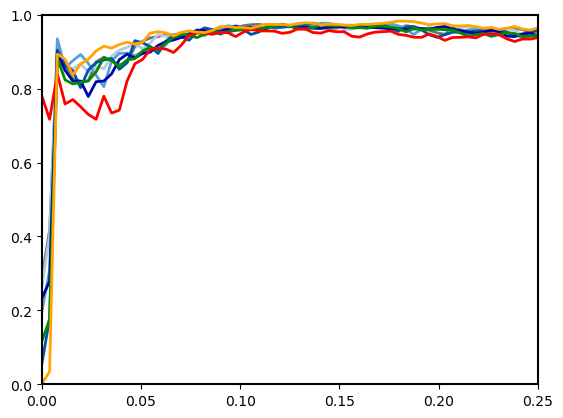

In [87]:
Szm = np.zeros(1024)
Szz = np.zeros(1024)
Smm = np.zeros(1024)

for i, exp in enumerate(experiments):
    
    # Extract the 1D time series for the current experiment (length 14500)
    z_exp = z[i, :]
    m_exp = m[i, :]
    
    # Slice into overlapping segments
    segments_z = np.array([z_exp[j : j + segment_length] for j in range(0, len(z_exp) - segment_length + 1, step_size)])
    segments_m = np.array([m_exp[j : j + segment_length] for j in range(0, len(m_exp) - segment_length + 1, step_size)])
    
    # Apply Hanning window
    windowed_z = segments_z * hanning_window
    windowed_m = segments_m * hanning_window
    
    # Perform FFT along the time axis (axis=1)
    num_segments = len(windowed_z) # 130
    Z = np.zeros((num_segments, segment_length), dtype=complex)
    M = np.zeros((num_segments, segment_length), dtype=complex)
    for i in range(num_segments):
        Z[i, :] = np.fft.fft(windowed_z[i, :])
        M[i, :] = np.fft.fft(windowed_m[i, :])
    
    Z = np.fft.fft(windowed_z, axis=1)
    M = np.fft.fft(windowed_m, axis=1)

    # Z_mean = Z.mean(axis=0)
    # M_mean = M.mean(axis=0)

    Szm = np.conj(Z) * (M)
    Szz = np.conj(Z) * (Z)
    Smm = np.conj(M) * (M)

    # Szm's shape is (window number, day number in each window)
    coherence_squared = (Szm.mean(axis=0).real**2 + Szm.mean(axis=0).imag**2) / (Szz.mean(axis=0) * Smm.mean(axis=0))

    plt.plot(freqs_shift, np.fft.fftshift(coherence_squared),color=exp["color"], label=exp["label"], linewidth=2)


plt.xlim([0,0.25])
plt.ylim([0,1])

# Phase diff

In [43]:
Szm.shape

(112, 1024)

(0.0, 90.0)

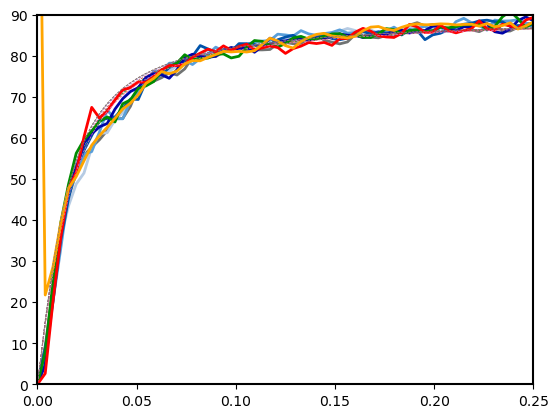

In [88]:
Szm = np.zeros(1024)
Szz = np.zeros(1024)
Smm = np.zeros(1024)

for i, exp in enumerate(experiments):
    
    # Extract the 1D time series for the current experiment (length 14500)
    z_exp = z[i, :]
    m_exp = m[i, :]
    
    # Slice into overlapping segments
    segments_z = np.array([z_exp[j : j + segment_length] for j in range(0, len(z_exp) - segment_length + 1, step_size)])
    segments_m = np.array([m_exp[j : j + segment_length] for j in range(0, len(m_exp) - segment_length + 1, step_size)])
    
    # Apply Hanning window
    windowed_z = segments_z * hanning_window
    windowed_m = segments_m * hanning_window
    
    # Perform FFT along the time axis (axis=1)
    num_segments = len(windowed_z) # 130
    Z = np.zeros((num_segments, segment_length), dtype=complex)
    M = np.zeros((num_segments, segment_length), dtype=complex)
    for j in range(num_segments):
        Z[j, :] = np.fft.fft(windowed_z[j, :])
        M[j, :] = np.fft.fft(windowed_m[j, :])
    
    Z = np.fft.fft(windowed_z, axis=1)
    M = np.fft.fft(windowed_m, axis=1)

    # Z_mean = Z.mean(axis=0)
    # M_mean = M.mean(axis=0)

    Szm = np.conj(Z) * (M)
    phase_diff = np.atan2(Szm.mean(axis=0).imag,  Szm.mean(axis=0).real) # np.arctan's domain si diff

    plt.plot(freqs_shift, np.rad2deg(np.fft.fftshift(phase_diff)), color=exp["color"], label=exp["label"], linewidth=2)

    plt.plot(freqs_shift, np.rad2deg(np.atan(tau_all[i] * 2 * np.pi * freqs_shift)), linestyle='--', linewidth=0.5)
plt.xlim([0,0.25])
plt.ylim([0,90])

# b value 

In [45]:
z.shape

(8, 58000)

In [89]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. Configuration for 6-hourly data
# ==========================================
steps_per_day = 4
chunk_days = 256
overlap_days = 128

chunk_steps = chunk_days * steps_per_day        # 1024 steps
overlap_steps = overlap_days * steps_per_day    # 512 steps
step_size = chunk_steps - overlap_steps         # 512 steps

# Define how many days of lag you want to calculate (LH2001 usually plots +/- 50 days)
max_lag_days = 30
max_lag_steps = max_lag_days * steps_per_day

# Generate the lag array in units of DAYS for plotting
lags_steps = np.arange(-max_lag_steps, max_lag_steps + 1)
lags_days = lags_steps / steps_per_day

# ==========================================
# 2. Calculate Averaged Cross-Correlation
# ==========================================
ccf_sum = np.zeros(len(lags_steps))
valid_chunks = 0

print(f"Dividing {len(z)} steps into {chunk_days}-day chunks with {overlap_days}-day overlaps...")

ccf_all = np.zeros((8, max_lag_days*4*2 + 1))
for i, exp in enumerate(experiments):
    
    # Extract the 1D time series for the current experiment (length 14500)
    z_exp = z[i, :]
    m_exp = m[i, :]
    
    # Loop through the time series
    for j in range(0, len(z_exp) - chunk_steps + 1, step_size):
        z_chunk = z_exp[j : j + chunk_steps]
        m_chunk = m_exp[j : j + chunk_steps]
        
        
        # 1. Calculate standard deviations for normalization
        std_z = np.std(z_chunk)
        std_m = np.std(m_chunk)
                
        # 2. Calculate full cross-covariance for the chunk
        # np.correlate(m, z) means positive lag = z leads m
        cov_full = np.correlate(m_chunk, z_chunk, mode='full') / chunk_steps
        
        # 3. Normalize to get correlation coefficient (-1 to 1)
        corr_full = cov_full / (std_z * std_m)
        
        # 4. Extract only the lags we care about (+/- max_lag_steps)
        center_idx = chunk_steps - 1
        corr_extracted = corr_full[center_idx - max_lag_steps : center_idx + max_lag_steps + 1]
        
        # Add to sum
        ccf_sum += corr_extracted
        valid_chunks += 1
    
    ccf_avg = ccf_sum / valid_chunks
    ccf_all[i] = ccf_avg

Dividing 8 steps into 256-day chunks with 128-day overlaps...


In [90]:
ccf_all.shape

(8, 241)

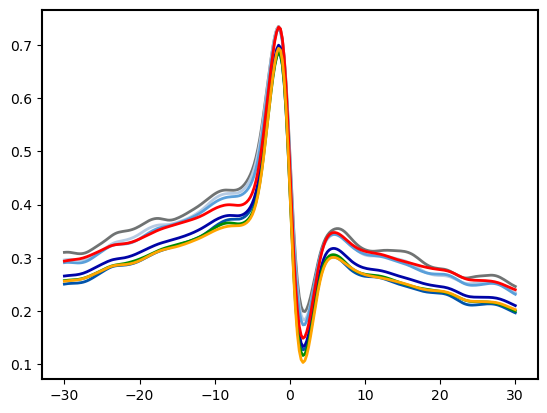

In [91]:
plt.figure()
for i, exp in enumerate(experiments):
    plt.plot(lags_days, ccf_all[i], color=exp["color"], label=exp["label"], linewidth=2)

In [92]:
tau_all

array([10.65704274, 10.50367698, 10.68913701, 10.92486842, 11.2386614 ,
       11.43705425, 10.37829129, 11.41393403])

Optimization terminated successfully.
         Current function value: 0.006794
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.005818
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.004709
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.003132
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.003359
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.002415
         Iterations: 24
         Function evaluations: 48
Optimization terminated successfully.
         Current function value: 0.003656
         Iterations: 24
         Function evaluations: 48
Optimization terminated successful

/tmp/ipykernel_347265/929742786.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_all[i] = b


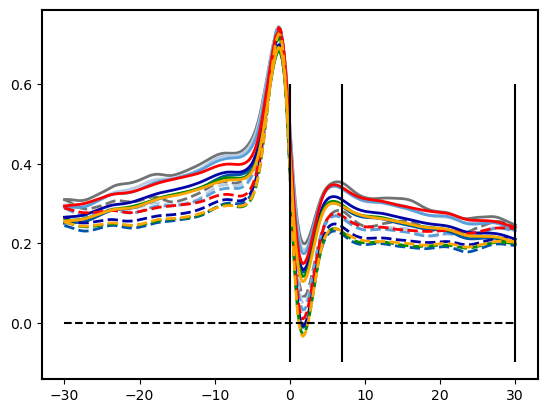

In [98]:
from scipy.optimize import minimize
from scipy import signal

b_ini = 0.2
sigma_inv = tau**-1 - b_ini

t = np.linspace(-30*4, 30*4, 241)

def converl(b,  c_zm, tau, t):
    con = np.convolve(c_zm, np.exp(-np.abs(t*0.25)/tau), mode="same")*0.25
    optimized_all = c_zm - b * (1-b*tau/2) * con
    # print(optimized_all.shape)
    return ((optimized_all[121 + 7*4 : 121 + 30*4] - optimized_all[121 + 30*4 - 1])**2).sum() 
    
# result_con = converl(b_ini, ccf_avg, tau_from_fig2, t)
num_day = z[0].shape[0]
b_all = np.zeros(8)

for i, exp in enumerate(experiments):
    res = minimize(converl, b_ini, method='nelder-mead', args=(ccf_all[i], tau_all[i], t),
                   options={'xatol': 1e-8, 'disp': True})
    b = res.x # 6hourly b
    b_all[i] = b
    c_zm_without = ccf_all[i] - b * (1 - b * tau_all[i]/2) * np.convolve(ccf_all[i], np.exp(-np.abs(t*0.25)/tau_all[i]), mode="same")*0.25

    C_zz_unnorm = signal.correlate(z[i], z[i], mode="same", method="fft")
    C_mm_unnorm = signal.correlate(m[i], m[i], mode="same", method="fft")
    
    # The max is always exactly at the center index for autocorrelation
    center_idx = len(C_zz_unnorm) // 2
    C_zz_0 = C_zz_unnorm / C_zz_unnorm[center_idx]

    center_idx = len(C_mm_unnorm) // 2
    C_mm_0 = C_mm_unnorm / C_mm_unnorm[center_idx]

    #
    c_zz_without = C_zz_0[num_day//2] - b * (1 - b* tau_all[i]/2)  * np.convolve(C_zz_0, np.exp(-np.abs(t*0.25)/tau_all[i]), mode="same")*0.25
    c_mm_without = C_mm_0[num_day//2] - b * (1 - b* tau_all[i]/2)  * np.convolve(C_mm_0, np.exp(-np.abs(t*0.25)/tau_all[i]), mode="same")*0.25
    c_zm_without = ((C_zz_0[num_day//2] * C_mm_0[num_day//2])/ (c_zz_without[num_day//2] * c_mm_without[num_day//2])) **0.5 * (ccf_all[i] - b * (1 - b * tau_all[i]/2) * np.convolve(ccf_all[i], np.exp(-np.abs(t*0.25)/tau_all[i]), mode="same")*0.25)

    plt.plot(lags_days, c_zm_without, linestyle='--', color=exp["color"], label=exp["label"], linewidth=2)
    plt.plot(lags_days, ccf_all[i], color=exp["color"], label=exp["label"], linewidth=2)

# plt.xlim()
plt.hlines(y=0, xmin=-30, xmax=30, color="Black", linestyle="--")
plt.vlines(x=0, ymin=-0.1, ymax=0.6, color="Black", linestyle="-")
plt.vlines(x=7, ymin=-0.1, ymax=0.6, color="Black", linestyle="-")
plt.vlines(x=30, ymin=-0.1, ymax=0.6, color="Black", linestyle="-")



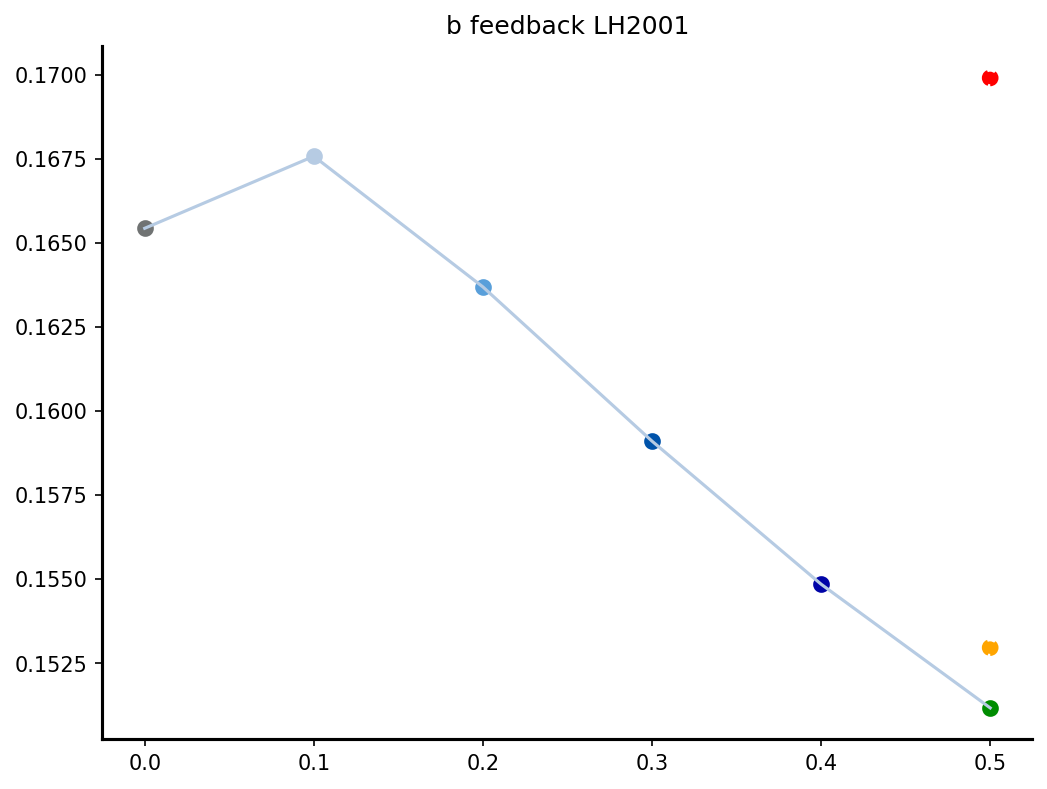

In [99]:
fig, ax = plt.subplots(1, figsize=(8,6), dpi=150.)
for i, exp in enumerate(experiments):
    # if i <= 5:
        ax.scatter(exp["L_val"], b_all[i], 
                color=exp["color"], linestyle=exp["linestyle"], label=exp["label"], linewidth=2)
ax.plot(np.linspace(0,0.5,6), b_all[:6], 
            color=pr_colors[1], linewidth=1.5)
ax.set_title("b feedback LH2001")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# ax.legend(loc="best", prop={'size': 7.5}, frameon=False, ncols=2)


In [164]:
z.shape

0.5